### 1 – Signal Simulation

##### Theory, Industrial Relevance & Mathematical Intuition
Ultrasonic testing (UT) is one of the most widely used non‑destructive evaluation (NDE) techniques in aerospace, oil & gas, and manufacturing. A piezoelectric transducer sends a high‑frequency sound pulse into a material; reflections (echoes) from boundaries or defects are recorded as A‑scan signals – amplitude vs. time.
A realistic A‑scan can be modelled as a sum of Gaussian‑modulated sinusoids (echoes), an exponential decay envelope (material attenuation), and noise.
Mathematically:


$$
s(t)=\sum_{k} A_k e^{-\alpha (t-t_k)^2}
\sin\!\left(2\pi f_c (t-t_k)+\phi_k\right)
+\eta(t)
$$

where:

- $A_k$ = amplitude of the $k$-th reflector
- $t_k$ = arrival time of the $k$-th reflector
- $\alpha$ = damping factor
- $f_c$ = centre frequency (typically 2–5 MHz)
- $\phi_k$ = phase of the $k$-th reflector
- $\eta(t)$ = electrical and random noise


Different defect types produce characteristic signatures: cracks give sharp, high‑amplitude echoes; porosity creates a cloud of small reflections; corrosion reduces back‑wall echo amplitude and may introduce multiple small peaks; inclusions cause a distinct mid‑wall echo with moderate damping.

Industrial relevance – Automating UT signal interpretation drastically reduces human error and inspection time, enabling inline quality control for safety‑critical components.



In [1]:
# We will generate 1000 signals per class (5000 total) and save them as .csv and .pkl.

Dataset created: 5000 signals, 501 time points each.


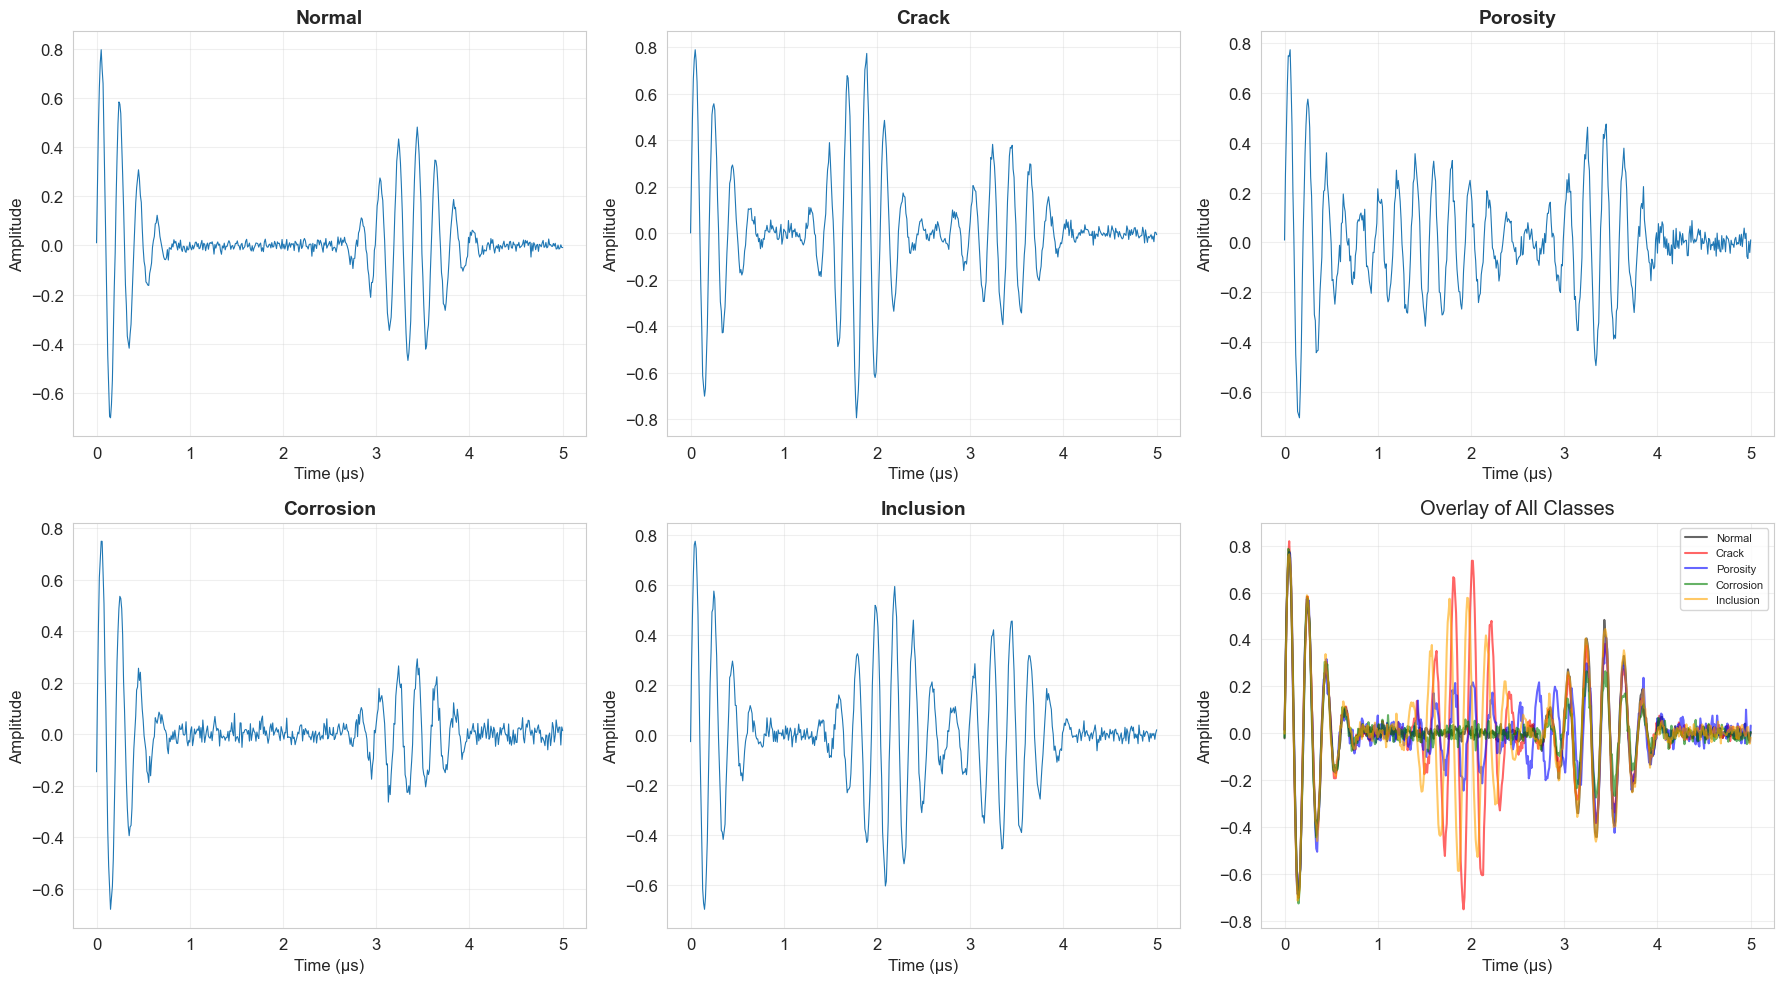

In [2]:
# ====================================================
# Notebook 01: Signal Simulation
# ====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, pickle
from pathlib import Path
from typing import Tuple, List

# Reproducibility
np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 5)})

# Create directory structure
Path("../data/raw").mkdir(parents=True, exist_ok=True)
Path("../data/processed").mkdir(parents=True, exist_ok=True)
Path("../models").mkdir(parents=True, exist_ok=True)
Path("../images").mkdir(parents=True, exist_ok=True)

# ====================================================
# Signal parameters
# ====================================================
SAMPLING_RATE = 100e6          # 100 MHz sampling
DURATION = 5e-6               # 5 µs time window
TIME = np.arange(0, DURATION, 1/SAMPLING_RATE)
NUM_SAMPLES = len(TIME)       # 500 points
CENTER_FREQ = 5e6             # 5 MHz transducer
DAMPING = 5e12                # Controls echo width
VELOCITY = 5900               # m/s (steel)
THICKNESS = 10e-3             # 10 mm plate
BACKWALL_TIME = 2 * THICKNESS / VELOCITY  # ≈ 3.39 µs

# ====================================================
# Helper functions to generate echo components
# ====================================================
def gaussian_echo(t: np.ndarray, t0: float, amp: float, fc: float, damping: float) -> np.ndarray:
    """
    Generate a single Gaussian‑modulated ultrasonic echo.

    Parameters:
        t : time array
        t0 : arrival time
        amp : amplitude scaling
        fc : centre frequency
        damping : controls temporal width (larger = narrower)
    Returns:
        echo signal
    """
    envelope = amp * np.exp(-damping * (t - t0) ** 2)
    carrier = np.sin(2 * np.pi * fc * (t - t0))
    return envelope * carrier

def apply_attenuation(signal: np.ndarray, t: np.ndarray, alpha: float = 1e5) -> np.ndarray:
    """
    Apply frequency‑independent attenuation (exponential decay).
    """
    return signal * np.exp(-alpha * t)

def add_noise(signal: np.ndarray, noise_level: float = 0.02) -> np.ndarray:
    """
    Add Gaussian white noise (electronic + random).
    """
    noise = np.random.normal(0, noise_level, size=signal.shape)
    return signal + noise

def generate_normal_signal() -> np.ndarray:
    """
    Normal material: only front‑wall and back‑wall echoes.
    """
    # Front wall echo (t=0) and back‑wall echo
    signal = (gaussian_echo(TIME, 0, 0.8, CENTER_FREQ, DAMPING) +
              gaussian_echo(TIME, BACKWALL_TIME, 0.6, CENTER_FREQ, DAMPING))
    signal = apply_attenuation(signal, TIME, alpha=8e4)
    signal = add_noise(signal, noise_level=0.015)
    return signal

def generate_crack_signal() -> np.ndarray:
    """
    Crack: sharp, high‑amplitude echo between front and back wall.
    """
    crack_time = np.random.uniform(0.4 * BACKWALL_TIME, 0.8 * BACKWALL_TIME)
    signal = (gaussian_echo(TIME, 0, 0.8, CENTER_FREQ, DAMPING) +
              gaussian_echo(TIME, crack_time, 0.9, CENTER_FREQ, DAMPING*1.5) +
              gaussian_echo(TIME, BACKWALL_TIME, 0.5, CENTER_FREQ, DAMPING))
    signal = apply_attenuation(signal, TIME, alpha=8e4)
    signal = add_noise(signal, noise_level=0.02)
    return signal

def generate_porosity_signal() -> np.ndarray:
    """
    Porosity: cluster of small echoes spread over a time region.
    """
    signal = (gaussian_echo(TIME, 0, 0.8, CENTER_FREQ, DAMPING) +
              gaussian_echo(TIME, BACKWALL_TIME, 0.6, CENTER_FREQ, DAMPING))
    # Add 3‑8 small random echoes
    num_pores = np.random.randint(3, 9)
    for _ in range(num_pores):
        t_pore = np.random.uniform(0.3 * BACKWALL_TIME, 0.85 * BACKWALL_TIME)
        amp = np.random.uniform(0.05, 0.2)
        signal += gaussian_echo(TIME, t_pore, amp, CENTER_FREQ, DAMPING * 0.8)
    signal = apply_attenuation(signal, TIME, alpha=8e4)
    signal = add_noise(signal, noise_level=0.03)
    return signal

def generate_corrosion_signal() -> np.ndarray:
    """
    Corrosion: back‑wall echo reduced in amplitude; may have early small echoes.
    """
    signal = (gaussian_echo(TIME, 0, 0.8, CENTER_FREQ, DAMPING) +
              gaussian_echo(TIME, BACKWALL_TIME, 0.35, CENTER_FREQ, DAMPING))  # weaker back‑wall
    # Random surface roughness echoes
    for _ in range(np.random.randint(0, 3)):
        t_r = np.random.uniform(0.05 * BACKWALL_TIME, 0.2 * BACKWALL_TIME)
        amp = np.random.uniform(0.05, 0.15)
        signal += gaussian_echo(TIME, t_r, amp, CENTER_FREQ, DAMPING * 0.7)
    signal = apply_attenuation(signal, TIME, alpha=8e4)
    signal = add_noise(signal, noise_level=0.025)
    return signal

def generate_inclusion_signal() -> np.ndarray:
    """
    Inclusion: a distinct mid‑wall echo with moderate damping.
    """
    inc_time = np.random.uniform(0.3 * BACKWALL_TIME, 0.7 * BACKWALL_TIME)
    signal = (gaussian_echo(TIME, 0, 0.8, CENTER_FREQ, DAMPING) +
              gaussian_echo(TIME, inc_time, 0.7, CENTER_FREQ, DAMPING) +
              gaussian_echo(TIME, BACKWALL_TIME, 0.6, CENTER_FREQ, DAMPING))
    signal = apply_attenuation(signal, TIME, alpha=8e4)
    signal = add_noise(signal, noise_level=0.02)
    return signal

# ====================================================
# Generate full dataset
# ====================================================
N_SAMPLES_PER_CLASS = 1000
CLASS_NAMES = ["Normal", "Crack", "Porosity", "Corrosion", "Inclusion"]

generators = [
    generate_normal_signal,
    generate_crack_signal,
    generate_porosity_signal,
    generate_corrosion_signal,
    generate_inclusion_signal
]

signals_list = []
labels_list = []

for class_idx, gen_func in enumerate(generators):
    for i in range(N_SAMPLES_PER_CLASS):
        sig = gen_func()
        signals_list.append(sig)
        labels_list.append(class_idx)

# Convert to DataFrame
df_signals = pd.DataFrame(signals_list, columns=[f"t{i}" for i in range(NUM_SAMPLES)])
df_signals["label"] = labels_list

# Save raw data
df_signals.to_csv("../data/raw/signals.csv", index=False)
with open("../data/raw/signals.pkl", "wb") as f:
    pickle.dump((signals_list, labels_list, TIME), f)

print(f"Dataset created: {df_signals.shape[0]} signals, {df_signals.shape[1]-1} time points each.")

# ====================================================
# Visualisations
# ====================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, gen_func) in enumerate(zip(CLASS_NAMES, generators)):
    ax = axes[idx]
    sig = gen_func()
    ax.plot(TIME * 1e6, sig, linewidth=0.8)
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.set_xlabel("Time (µs)")
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.3)

# Overlay comparison of all classes
ax_overlay = axes[5]
colors = ['black', 'red', 'blue', 'green', 'orange']
for idx, gen_func in enumerate(generators):
    sig = gen_func()
    ax_overlay.plot(TIME * 1e6, sig, color=colors[idx], alpha=0.6, label=CLASS_NAMES[idx])
ax_overlay.set_title("Overlay of All Classes")
ax_overlay.legend(loc='upper right', fontsize=8)
ax_overlay.set_xlabel("Time (µs)")
ax_overlay.set_ylabel("Amplitude")
ax_overlay.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../images/sample_signals.png", dpi=300)
plt.show()

### Interpretation of Results

**Normal:** only front‑wall and back‑wall echoes, clear exponential decay.

**Crack:** a sharp mid‑wall peak, easily distinguishable.

Porosity:** many small, overlapping reflections, “noisy” appearance.

**Corrosion:** back‑wall amplitude significantly reduced; possible small surface echoes.

**Inclusion:** a well‑separated mid‑wall echo but with less abrupt damping than a crack.